In [ ]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import pandas as pd
import pickle
import copy

from imports import *
from config import dir_config, ephys_config
from src.utils import dpca_utils, dpca_plot_utils

In [ ]:
compiled_dir  = Path(dir_config.data.compiled)
processed_dir = Path(dir_config.data.processed)

## Load data

Data loading stays in the notebook. The utils start after you have
`session_metadata`, `neuron_metadata`, `ephys`, and the trial-info dicts.

In [ ]:
session_to_exclude = ["210210_GP_JP", "241209_GP_TZ"]

session_metadata = pd.read_csv(Path(processed_dir, "sessions_metadata.csv"))
session_metadata = session_metadata[~session_metadata.session_id.isin(session_to_exclude)].reset_index(drop=True)

neuron_metadata = pd.read_csv(Path(processed_dir, "neuron_metadata.csv"))
neuron_metadata = neuron_metadata[~neuron_metadata.session_id.isin(session_to_exclude)].reset_index(drop=True)

with open(Path(processed_dir, "glm_hmm_models", "glm_hmm_masked_final.pkl"), "rb") as f:
    glm_hmm = pickle.load(f)
glm_hmm_original = copy.deepcopy(glm_hmm)

with open(Path(processed_dir, "ephys_neuron_wise.pkl"), "rb") as f:
    ephys = pickle.load(f)

## Extract trial info (blocks or glm-hmm states)

In [ ]:
data = glm_hmm["data"]

# HMM states — also flips sign for awayRF sessions in-place on glm_hmm["data"]
# compiled_dir loads reaction_time from trial CSVs (required by get_trial_num)
biased_state_trial_info, unbiased_state_trial_info, state_occupancy = \
    dpca_utils.extract_hmm_state_trial_info(session_metadata, glm_hmm_original, data,
                                            compiled_dir=compiled_dir)

# Blocks from prob_toRF (run after extract_hmm_state_trial_info so awayRF sign flip is applied)
equal_block_trial_info, unequal_block_trial_info = \
    dpca_utils.extract_block_trial_info(data, session_metadata["session_id"])

## Shared setup

In [59]:
toRF_sessions  = session_metadata.session_id[session_metadata.prior_direction == "toRF"]
awayRF_sessions = session_metadata.session_id[session_metadata.prior_direction == "awayRF"]

alignments = list(ephys_config["alignment_settings_GP"].keys())  # ['baseline','visual','cue','response']
marginalization_keys = ['b', 's', 'c', 't']

condition_dict_states = {
    "state_values": ["biased", "unbiased"],
    "coherences":   [0, 0.06, 0.2, 0.5],
    "choices":      ["awayRF", "toRF"],
}

state_trial_info = {
    "biased":   biased_state_trial_info,
    "unbiased": unbiased_state_trial_info,
}

COH_LABELS = ["0%", "6%", "20%", "50%"]


---
## All neurons, HMM states — toRF & awayRF sessions

In [60]:
_out = Path("../dissemination/dpca/dpca_toRF_session_all_neuron")
_out.mkdir(parents=True, exist_ok=True)
_out_away = Path("../dissemination/dpca/dpca_awayRF_session_all_neuron")
_out_away.mkdir(parents=True, exist_ok=True)
_dpca_dir = Path(processed_dir) / 'dpca'
_dpca_dir.mkdir(parents=True, exist_ok=True)

# baseline excluded from self-projection & cross-projection (still fit/used for variance
# explained above)
alignments_no_baseline = [a for a in alignments if a != 'baseline']

In [61]:
neuron_ids = dpca_utils.get_neuron_ids(neuron_metadata, toRF_sessions)

avg, tw = dpca_utils.create_dpca_matrix(
    toRF_sessions, condition_dict_states, neuron_ids,
    state_trial_info, neuron_metadata, ephys, ephys_config,
    condition_type="states",
)
fit_avg, fit_tw, full_avg, full_tw = dpca_utils.clean_dpca_data(avg, tw, alignments)

dpca_results  = dpca_utils.fit_dpca_all_alignments(fit_avg, fit_tw, alignments, marginalization_keys=marginalization_keys)
projections   = dpca_utils.cross_period_projection(dpca_results, fit_avg, alignments)
time_axes     = dpca_utils.build_time_axes(fit_avg, ephys_config)


In [62]:
neuron_ids_away = dpca_utils.get_neuron_ids(neuron_metadata, awayRF_sessions)
print(f"awayRF neurons: {len(neuron_ids_away)}")

avg_away, tw_away = dpca_utils.create_dpca_matrix(
    awayRF_sessions, condition_dict_states, neuron_ids_away,
    state_trial_info, neuron_metadata, ephys, ephys_config,
    condition_type="states",
)
fit_avg_away, fit_tw_away, _, _ = dpca_utils.clean_dpca_data(avg_away, tw_away, alignments)

dpca_results_away = dpca_utils.fit_dpca_all_alignments(
    fit_avg_away, fit_tw_away, alignments, marginalization_keys=marginalization_keys
)
projections_away = dpca_utils.cross_period_projection(dpca_results_away, fit_avg_away, alignments)
time_axes_away = dpca_utils.build_time_axes(fit_avg_away, ephys_config)

awayRF neurons: 68


### Variance explained

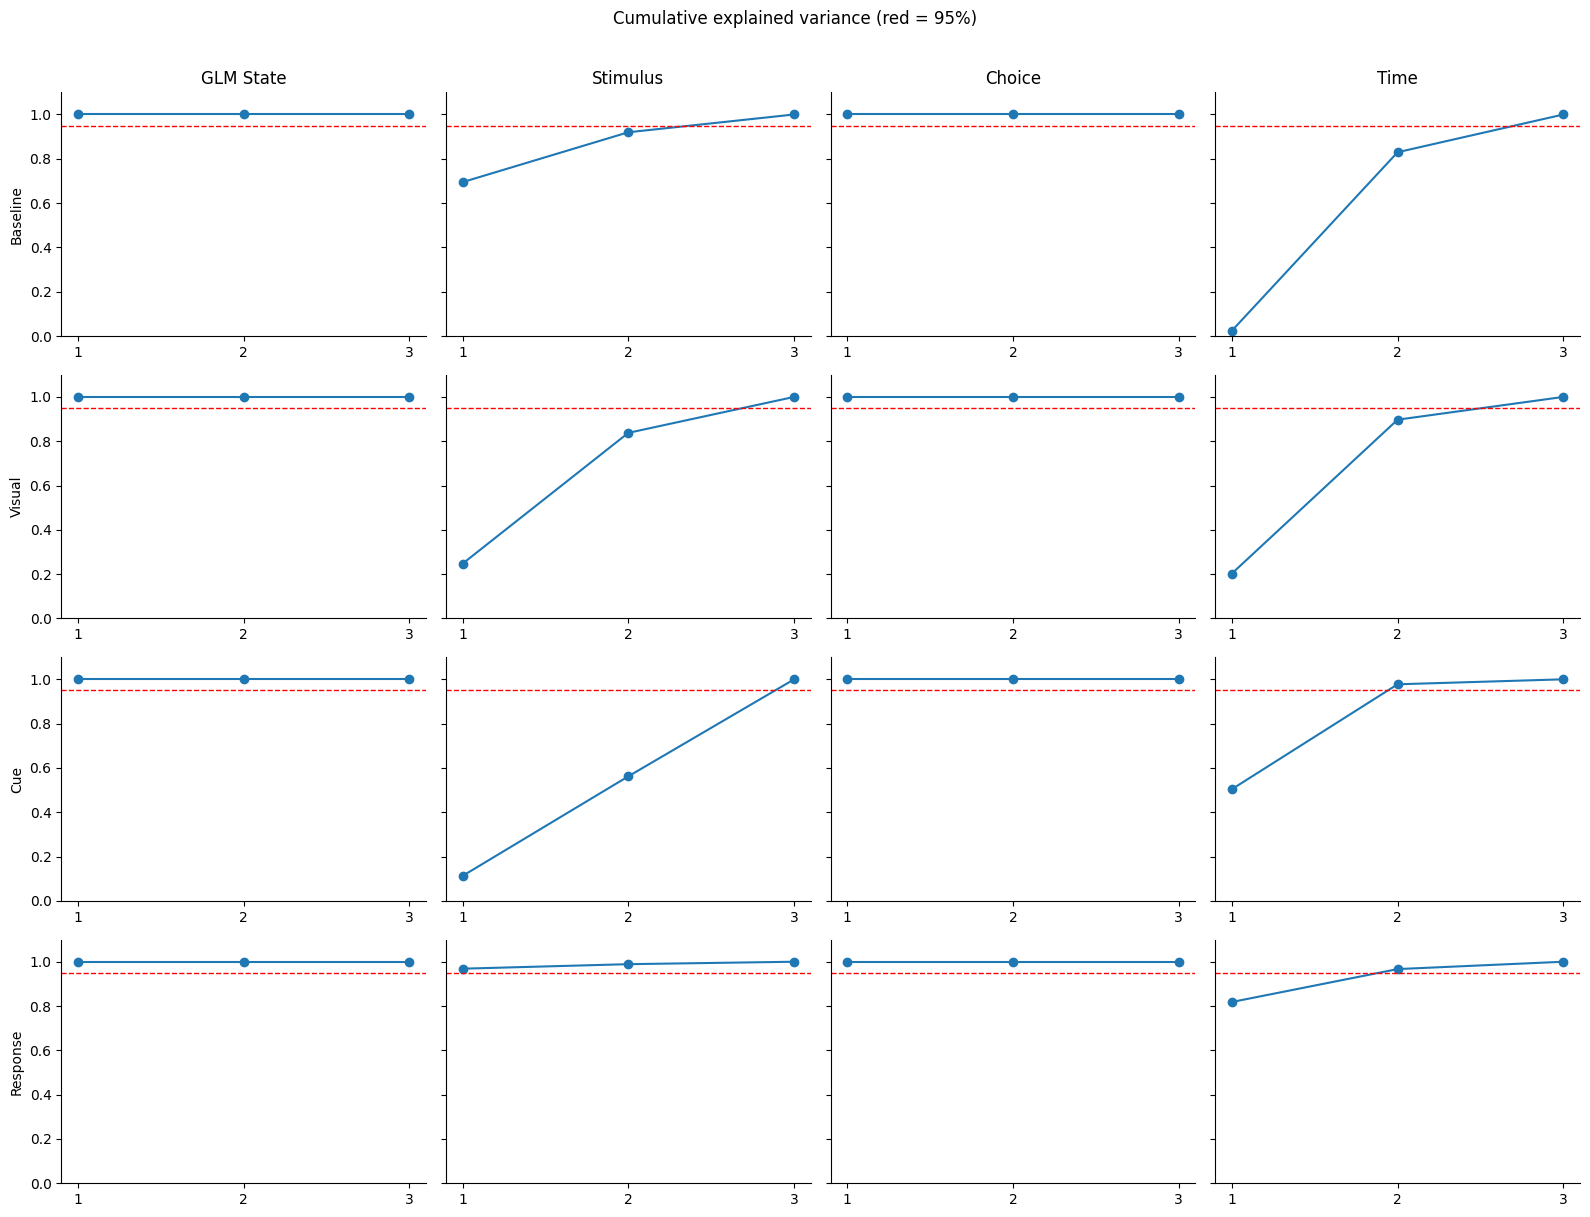

In [63]:
margs_to_plot = ['b', 's', 'c', 't']
n_components  = 3
fig = dpca_plot_utils.plot_variance_explained(dpca_results, alignments, margs_to_plot, n_components=n_components)
plt.show()
# fig.savefig(_out / "variance_explained.png", dpi=150, bbox_inches="tight")
plt.close(fig)

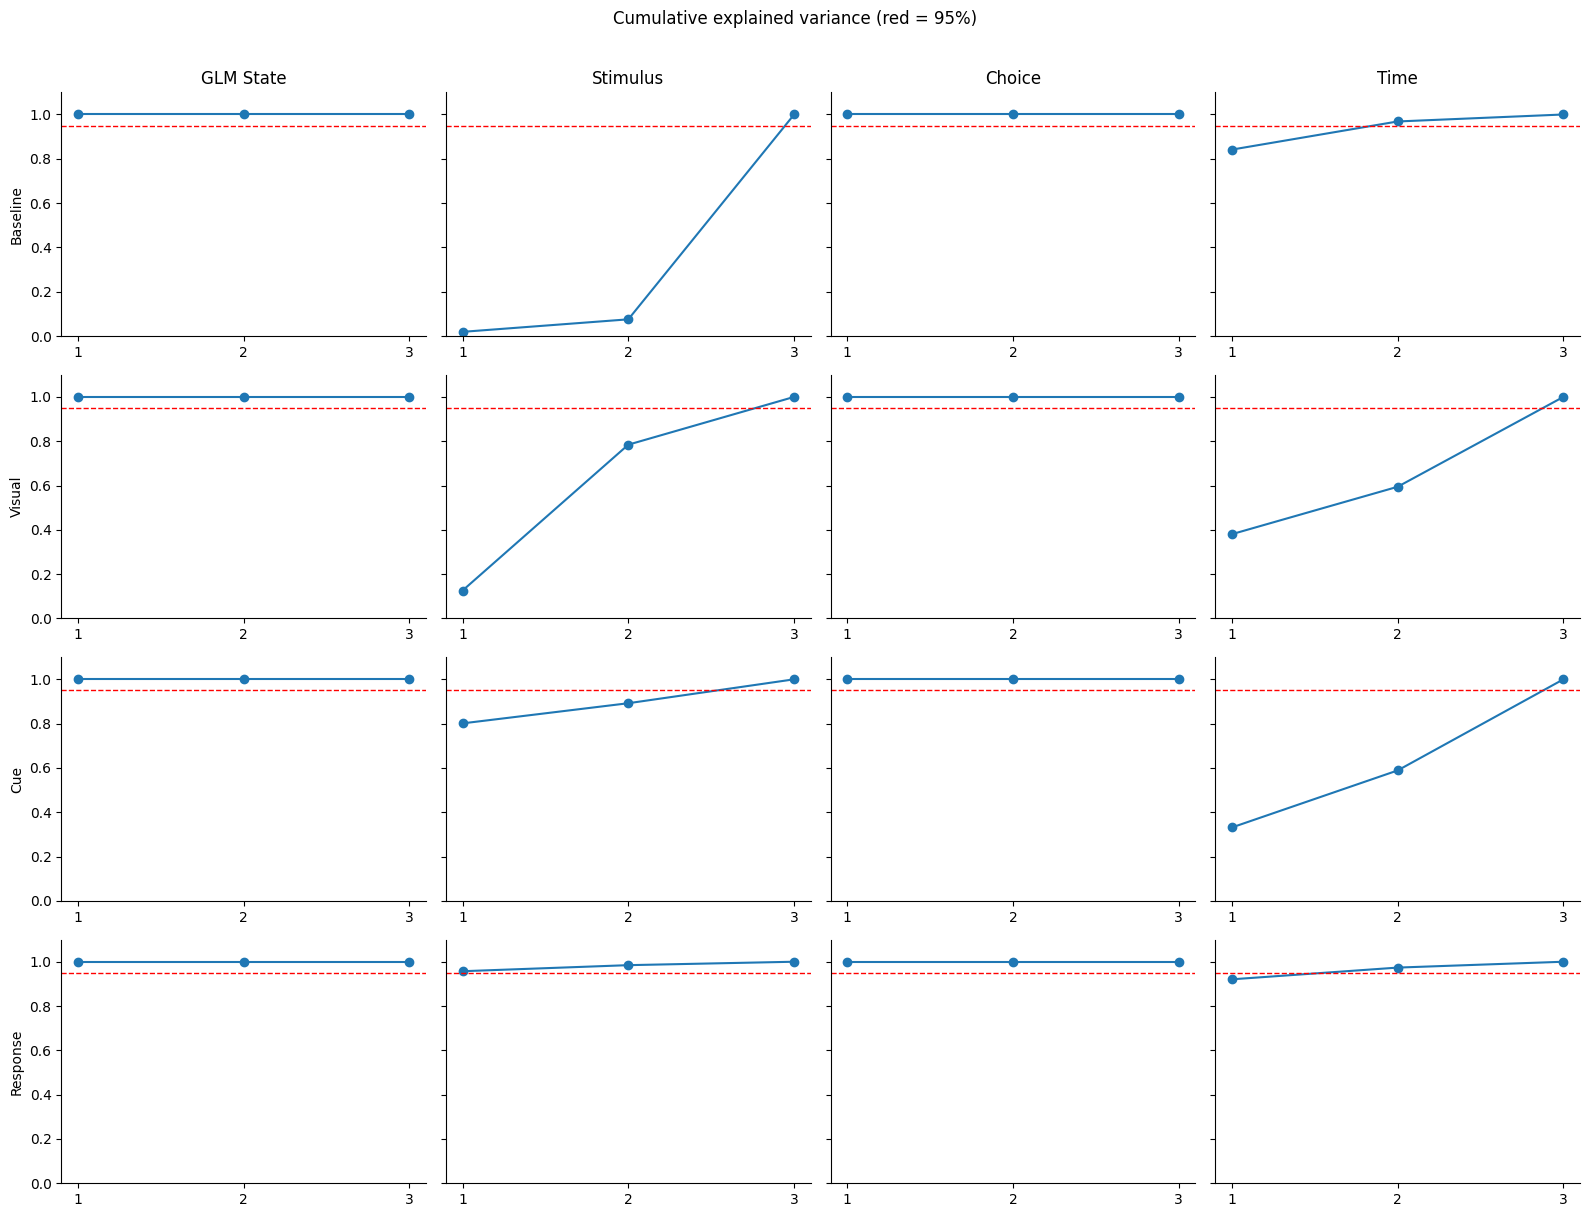

In [64]:
fig = dpca_plot_utils.plot_variance_explained(dpca_results_away, alignments, ['b', 's', 'c', 't'], n_components=3)
plt.show()
# fig.savefig(_out_away / "variance_explained.png", dpi=150, bbox_inches="tight")
plt.close(fig)

### Self-projection

In [65]:
_sig_path = _dpca_dir / "toRF_session_all_neuron_significance_masks.pkl"

if _sig_path.exists():
    with open(_sig_path, "rb") as f:
        significance_masks = pickle.load(f)
    print("Loaded significance_masks from cache.")
else:
    significance_masks = {}
    for alignment in alignments:
        dpca_model = dpca_results[alignment]["model"]
        print(f"Computing significance masks for {alignment} alignment...")
        significance_masks[alignment], _, _ = \
            dpca_utils.dpca_significance_analysis(
                copy.deepcopy(dpca_model), fit_avg[alignment], fit_tw[alignment],
                n_shuffles=100, n_splits=50, n_consecutive=1,
                keys=['b', 's', 'c'],
                key_groups={'s': [[0, 1], [2, 3]]},
                smooth_sigma=10,
            )
    with open(_sig_path, "wb") as f:
        pickle.dump(significance_masks, f)
    print(f"Saved → {_sig_path}")

Loaded significance_masks from cache.


In [66]:
# Significant bin counts per alignment / marginalization (PC1)
for alignment in alignments:
    for key in ['b', 's', 'c']:
        n_sig = significance_masks[alignment][key][0].sum()
        print(f"  {alignment}/{key}: {n_sig} significant bins (PC1)")


  baseline/b: 251 significant bins (PC1)
  baseline/s: 12 significant bins (PC1)
  baseline/c: 200 significant bins (PC1)
  visual/b: 251 significant bins (PC1)
  visual/s: 38 significant bins (PC1)
  visual/c: 242 significant bins (PC1)
  cue/b: 359 significant bins (PC1)
  cue/s: 114 significant bins (PC1)
  cue/c: 359 significant bins (PC1)
  response/b: 310 significant bins (PC1)
  response/s: 310 significant bins (PC1)
  response/c: 310 significant bins (PC1)


In [67]:
_sig_away_path = _dpca_dir / "awayRF_session_all_neuron_significance_masks.pkl"

if _sig_away_path.exists():
    with open(_sig_away_path, "rb") as f:
        sig_away = pickle.load(f)
    print("Loaded sig_away from cache.")
else:
    sig_away = {}
    for alignment in alignments:
        print(f"  sig: {alignment}...")
        sig_away[alignment], _, _ = dpca_utils.dpca_significance_analysis(
            copy.deepcopy(dpca_results_away[alignment]["model"]),
            fit_avg_away[alignment], fit_tw_away[alignment],
            n_shuffles=100, n_splits=50, n_consecutive=1,
            keys=['b', 's', 'c'], key_groups={'s': [[0, 1], [2, 3]]},
            smooth_sigma=10,
        )
    with open(_sig_away_path, "wb") as f:
        pickle.dump(sig_away, f)
    print(f"Saved → {_sig_away_path}")

Loaded sig_away from cache.


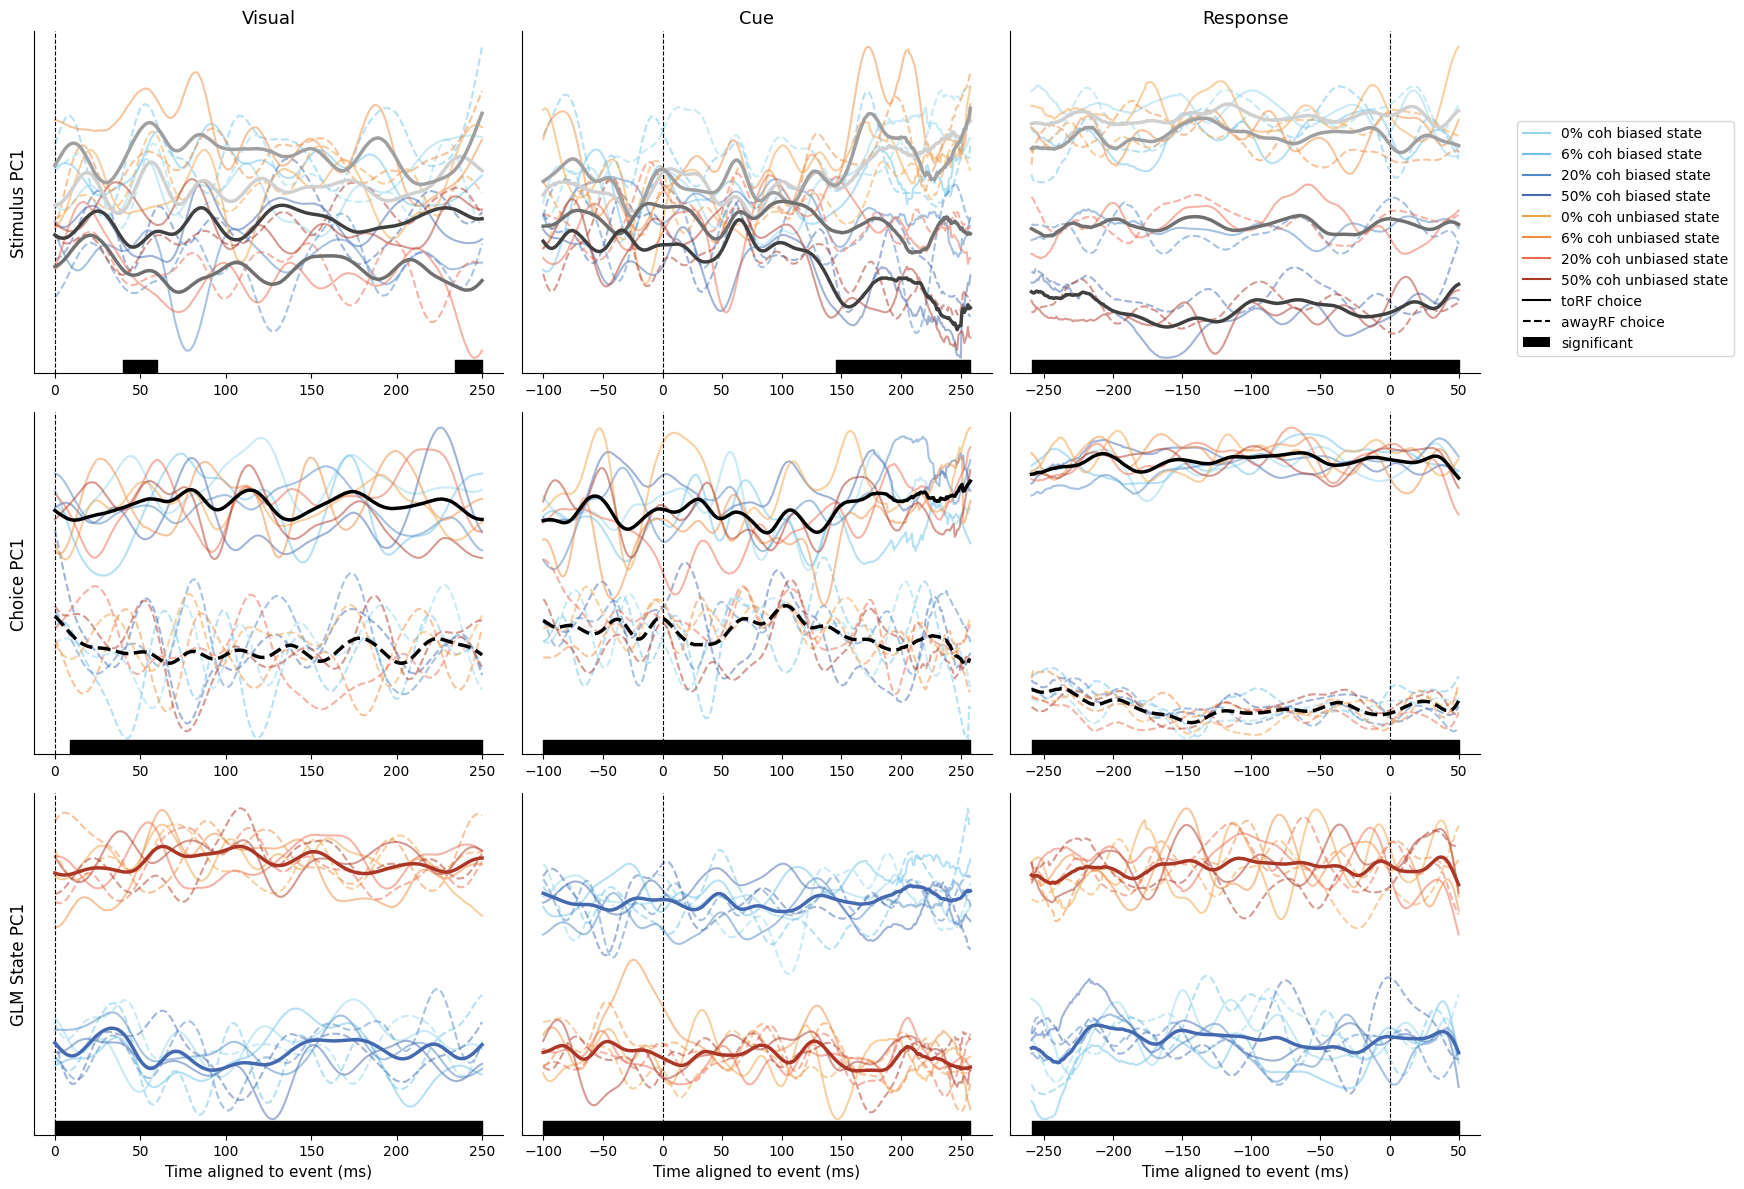

In [68]:
PC = 0
margs_to_plot = ['s', 'c', 'b']

fig = dpca_plot_utils.plot_self_projection(
    projections, time_axes, alignments_no_baseline, margs_to_plot,
    significance_masks=significance_masks, PC=PC,
    coh_labels=COH_LABELS,
)
plt.show()
# fig.savefig(_out / "self_projection.png", dpi=150, bbox_inches="tight")
# plt.close(fig)
# print(f"Saved → {_out / 'self_projection.png'}")

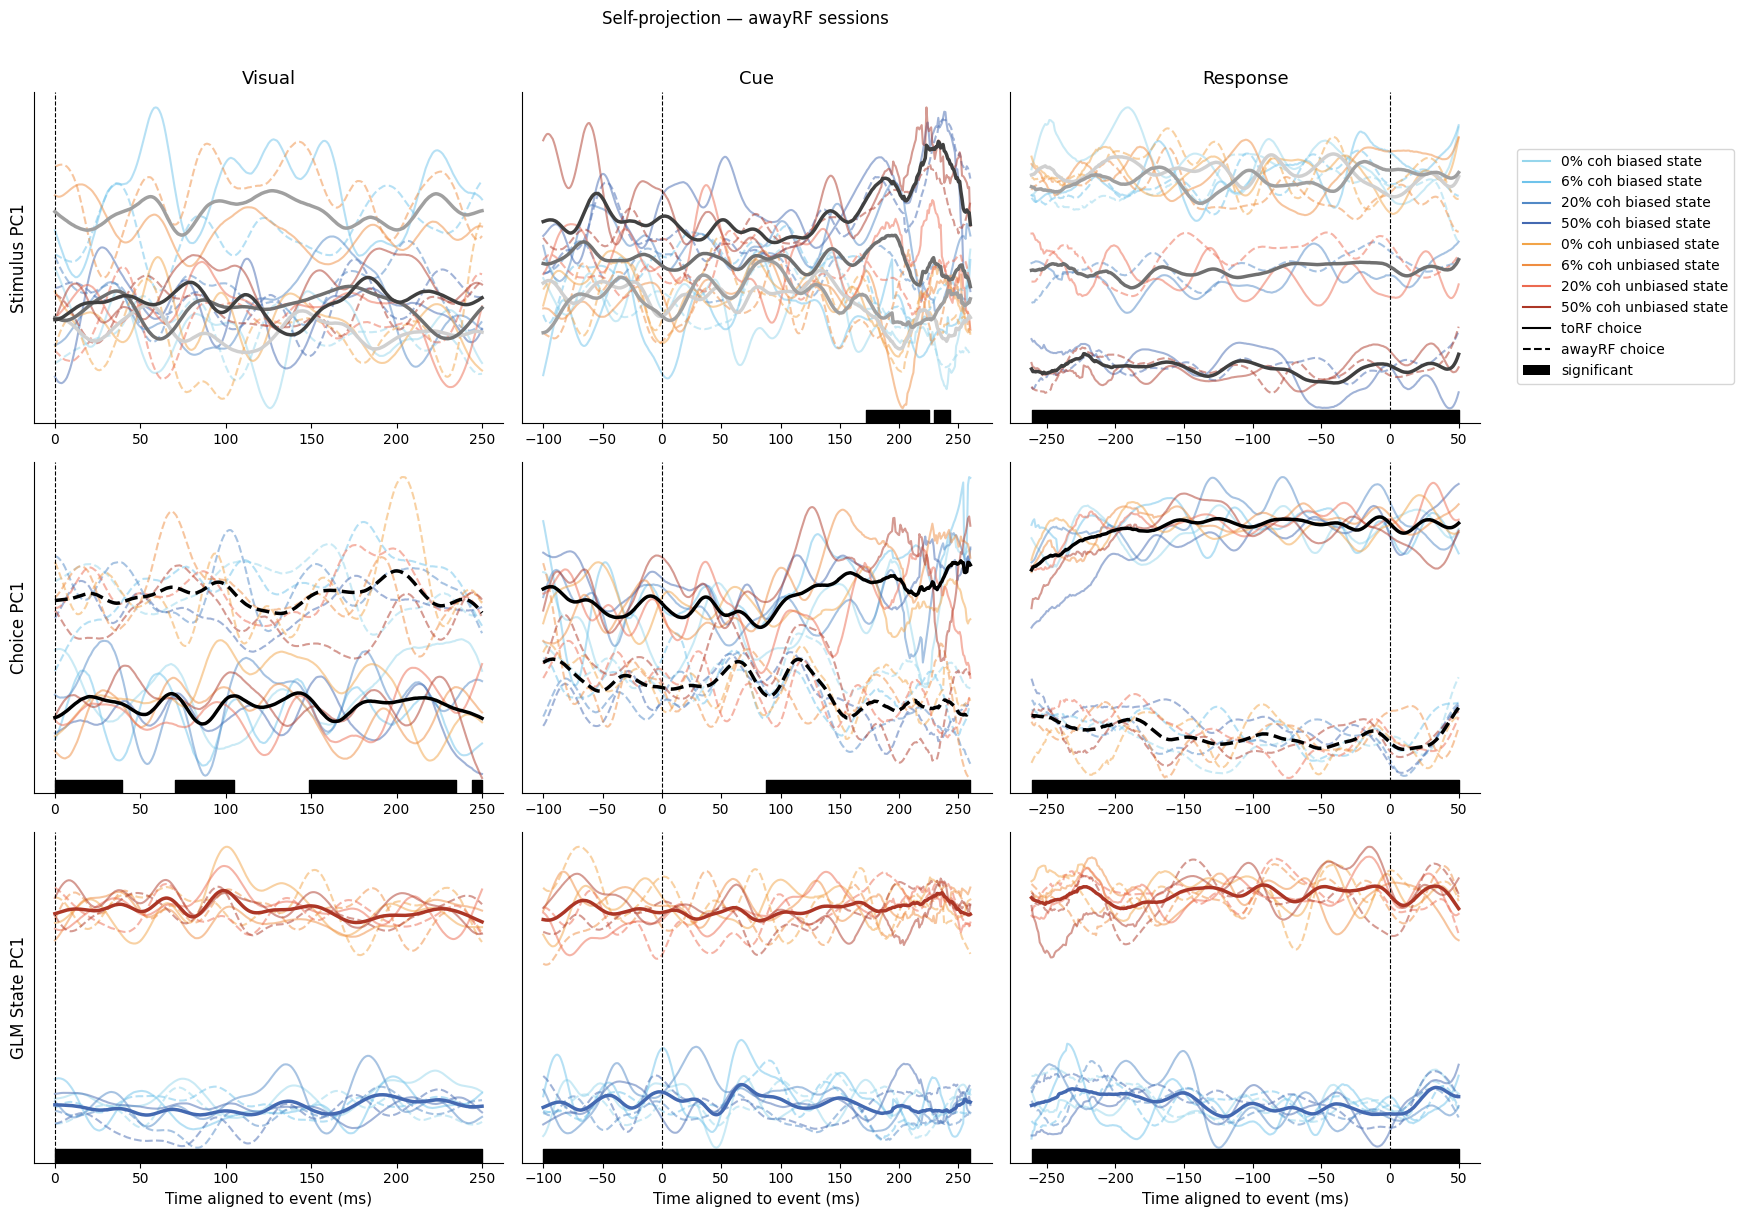

In [69]:
fig = dpca_plot_utils.plot_self_projection(
    projections_away, time_axes_away, alignments_no_baseline, ['s', 'c', 'b'],
    significance_masks=sig_away, PC=0, coh_labels=COH_LABELS,
    title="Self-projection — awayRF sessions",
)
plt.show()
# fig.savefig(_out_away / "self_projection.png", dpi=150, bbox_inches="tight")
plt.close(fig)

In [ ]:
# ── Self-projection with 95% CI band on the thick condition means (Example 1 only) ──
# The band is the analytic SEM of the condition-balanced marginal projection (the thick
# line), propagated from per-cell trial statistics in fit_tw — same trials the sig test
# uses. Bands pulling apart = the condition means separate = encoding onset for that
# variable. Notebook-local so it does NOT affect the other self-projection figures.
#
#   thick(v,t) = sum_n w_n * Xbar_n(v,t),   w_n = D[marg][:, PC]
#   var(thick) = sum_n w_n^2 * (1/K^2) * sum_cells( s2_cell / n_cell )
# See dpca_utils.dpca_significance_analysis for the matching condition-balanced collapse.

# cell axes of fit_tw after trial-averaging: 0=neuron 1=state(b) 2=coh(s) 3=choice(c) 4=time
# collapse the NON-key conditions for each marginalization (equal weight per condition):
_MARG_COLLAPSE = {'s': (1, 3), 'c': (1, 2), 'b': (2, 3)}

# sequential purple ramp (light->dark = low->high coherence) instead of dpca_plot_utils'
# greyscale _STIM_GREYS — greys were nearly indistinguishable once overlapping semi-transparent
# CI bands blended together. Purple keeps it visually distinct from the blue/orange used for
# biased/unbiased state below. 20% coh pulled further from 0%/6% (bigger jump into medium-dark)
# per explicit request — 0/6 stay closer together, 20/50 both pull darker/more saturated.
# 0% coh's shade must stay dark enough to be visible against the white figure background —
# a near-white ramp start (e.g. #efedf5) is invisible/reads as a blank "white trace".
_STIM_COLORS = ["#c4c2df", "#9e9ac8", "#6a51a3", "#3f007d"]


def thick_line_sem(trialX, w, collapse_axes):
    """Analytic SEM of the condition-balanced marginal projection (thick line).

    trialX        : (n_trial, n_neuron, n_state, n_coh, n_choice, n_time)  = fit_tw[align]
    w             : (n_neuron,) axis loading = dpca_results[align]['model'].D[marg][:, PC]
    collapse_axes : non-key condition axes to average over (cell space, see _MARG_COLLAPSE)
    returns sem   : (n_target_vals, n_time)   aligned with the thick-line order
    """
    cell_mean = np.nanmean(trialX, axis=0)                 # (neuron, b, s, c, time)
    cell_var  = np.nanvar(trialX,  axis=0, ddof=1)         # per-cell trial variance
    cell_cnt  = np.sum(~np.isnan(trialX), axis=0)          # per-cell trial count
    with np.errstate(invalid='ignore', divide='ignore'):
        cell_sem2 = cell_var / cell_cnt                    # SEM^2 of each cell mean
    K = np.sum(~np.isnan(cell_mean), axis=collapse_axes, keepdims=True)  # #valid cells
    with np.errstate(invalid='ignore', divide='ignore'):
        var_Xbar = np.nansum(cell_sem2, axis=collapse_axes, keepdims=True) / K**2
    var_Xbar = np.squeeze(var_Xbar, axis=collapse_axes)    # (neuron, target, time)
    var_thick = np.tensordot(w**2, var_Xbar, axes=([0], [0]))  # (target, time)
    return np.sqrt(var_thick)


def _self_projection_flip(projections, alignment, marg, PC):
    """Sign (+-1) for this (alignment, marg, PC) so THIS epoch's panel satisfies
    toRF > awayRF (c), biased > unbiased (b), high coh > low coh (s). dPCA fits each
    alignment's axes independently, so the sign is independently arbitrary per epoch too —
    a single sign aggregated across epochs can leave an individual epoch's ordering
    backwards even when most epochs are correct (e.g. cue was wrong under the aggregated
    version). Deciding per-epoch guarantees every panel satisfies the requested ordering,
    which in practice keeps the trend consistent across epochs too, since real encoding
    axes normally already agree and this only corrects genuine axis-sign flips."""
    data_pc = projections[alignment][alignment][marg][PC]  # (n_states, n_coh, n_choices, n_time)
    if marg == 's':
        m = np.nanmean(data_pc, axis=(0, 2))          # (n_coh, time), 0=lowest..-1=highest coh
        diff = np.nanmean(m[-1] - m[0])
    elif marg == 'c':
        m = np.nanmean(data_pc, axis=(0, 1))          # (n_choices, time), 0=awayRF,1=toRF
        diff = np.nanmean(m[1] - m[0])
    else:  # 'b'
        m = np.nanmean(data_pc, axis=(1, 2))          # (n_states, time), 0=biased,1=unbiased
        diff = np.nanmean(m[0] - m[1])
    return -1.0 if diff < 0 else 1.0


def _plot_self_projection_ci_marg(ax_row, marg, alignments, projections, time_axes,
                                  fit_tw, dpca_results, significance_masks, PC,
                                  n_states, n_coh, coh_labels, biased_colors, unbiased_colors,
                                  trace_alpha, z, show_thin):
    """Draw one marg's row of subplots (one alignment per column) onto ax_row."""
    dpu = dpca_plot_utils
    n_cols = len(alignments)
    for col, alignment in enumerate(alignments):
        Z, time = projections[alignment][alignment], time_axes[alignment]
        D_model, trialX = dpca_results[alignment]["model"].D, fit_tw[alignment]
        ax = ax_row[col]
        flip = _self_projection_flip(projections, alignment, marg, PC)
        data_pc = flip * Z[marg][PC]                       # (n_states, n_coh, n_choices, n_time)
        if show_thin:
            dpu.plot_dpca_traces(ax, time, data_pc, n_states, n_coh,
                                 biased_colors, unbiased_colors, alpha=trace_alpha)
        sem = thick_line_sem(trialX, D_model[marg][:, PC], _MARG_COLLAPSE[marg])  # (target,time)

        if marg == 's':
            mean = np.nanmean(data_pc, axis=(0, 2))        # (n_coh, time)
            colors, styles = [_STIM_COLORS[s] for s in range(n_coh)], ["-"] * n_coh
            labels = [f"{coh_labels[s]} coh" for s in range(n_coh)]
        elif marg == 'c':
            mean = np.nanmean(data_pc, axis=(0, 1))        # (n_choices, time)  0=awayRF,1=toRF
            colors, styles = ["black", "black"], ["--", "-"]
            labels = ["awayRF choice", "toRF choice"]
        else:  # 'b'
            mean = np.nanmean(data_pc, axis=(1, 2))        # (n_states, time)
            colors, styles = [biased_colors[-1], unbiased_colors[-1]], ["-"] * n_states
            labels = ["biased state", "unbiased state"]
        for k in range(mean.shape[0]):
            ax.plot(time, mean[k], color=colors[k], linestyle=styles[k], linewidth=2.5,
                    label=labels[k])
            ax.fill_between(time, mean[k] - z * sem[k], mean[k] + z * sem[k],
                            color=colors[k], alpha=0.22, linewidth=0)
        if col == n_cols - 1:                              # one legend per row, outside the figure
            ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

        if significance_masks is not None and marg in significance_masks.get(alignment, {}):
            dpu.bar_significance(ax, time, significance_masks[alignment][marg][PC])
        if not show_thin:
            ax.axvline(0, color="k", linestyle="--", linewidth=0.8)
            ax.spines[["top", "right"]].set_visible(False)
        ax.set_yticks([])
        ax.set_title(dpu.ALIGN_LABELS.get(alignment, alignment), fontsize=13)
        if col == 0:
            ax.set_ylabel(f"{dpu.MARG_LABELS.get(marg, marg)} PC{PC + 1}", fontsize=12)
        ax.set_xlabel("Time aligned to event (ms)", fontsize=11)


def plot_self_projection_ci(projections, time_axes, alignments, margs_to_plot,
                            fit_tw, dpca_results, significance_masks=None, PC=0,
                            n_states=2, n_coh=4, coh_labels=None, title=None,
                            trace_alpha=0.15, z=1.96, show_thin=True):
    """plot_self_projection + a z*SEM shaded band on each thick condition mean, split into
    ONE FIGURE PER MARG (returns {marg: fig}) instead of one combined figure — each figure
    has alignments as columns. Each (alignment, marg, PC) panel has its own sign flip (see
    _self_projection_flip) so toRF>awayRF, biased>unbiased, high coh>low coh in EVERY panel.
    One legend per row (its conditions), placed outside the rightmost subplot.
    Mirrors dpca_plot_utils.plot_self_projection. Displays each figure as it's built
    (matches the _plot_psth_grid convention elsewhere in this notebook)."""
    dpu = dpca_plot_utils
    biased_colors, unbiased_colors = dpu.BIASED_COLORS[:n_coh], dpu.UNBIASED_COLORS[:n_coh]
    if coh_labels is None:
        coh_labels = [f"coh{i}" for i in range(n_coh)]
    n_cols = len(alignments)

    figs = {}
    for marg in margs_to_plot:
        fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4), squeeze=False)
        _plot_self_projection_ci_marg(
            axes[0], marg, alignments, projections, time_axes, fit_tw, dpca_results,
            significance_masks, PC, n_states, n_coh, coh_labels,
            biased_colors, unbiased_colors, trace_alpha, z, show_thin,
        )
        marg_title = f"{title} — {dpu.MARG_LABELS.get(marg, marg)}" if title else dpu.MARG_LABELS.get(marg, marg)
        fig.suptitle(marg_title, y=1.05)
        fig.tight_layout(rect=[0, 0, 0.88, 1])  # leave room on the right for the row legend
        plt.show()
        figs[marg] = fig
    return figs

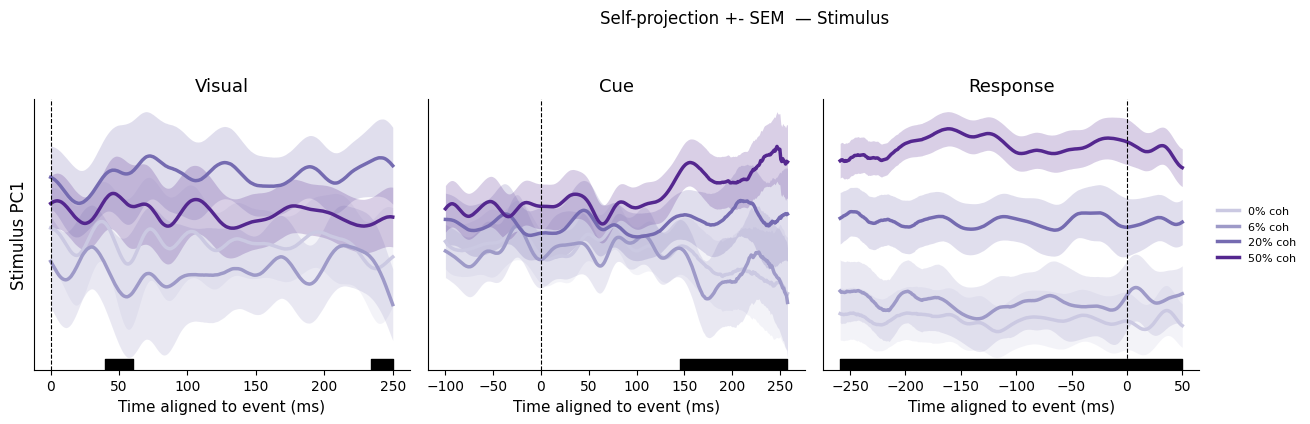

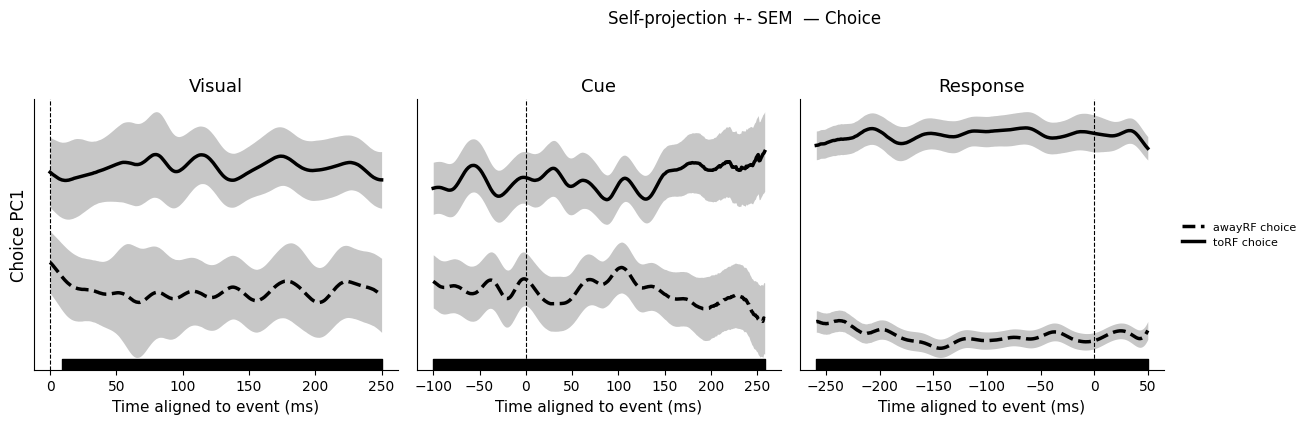

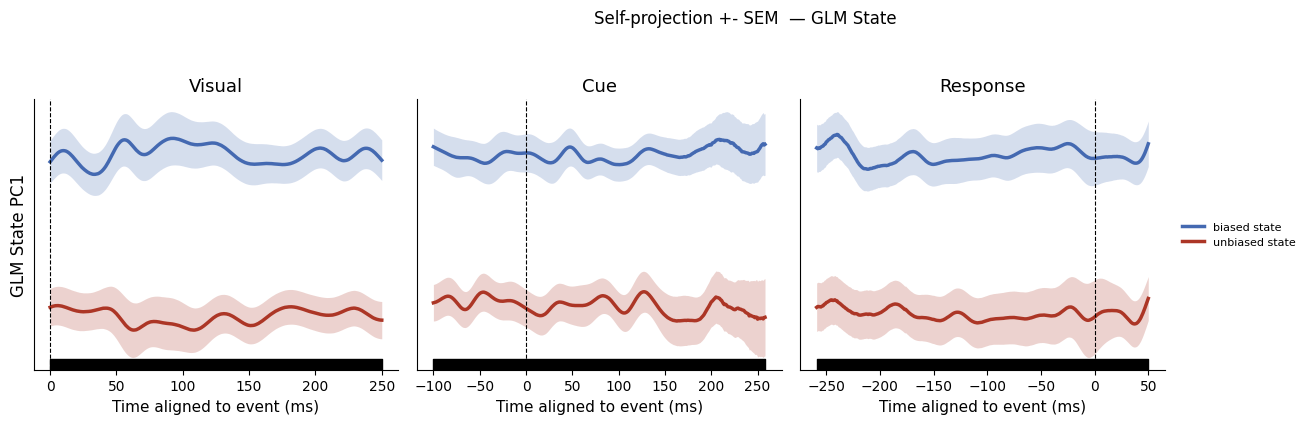

Saved → ../dissemination/dpca/dpca_toRF_session_all_neuron/self_projection_ci_s.png
Saved → ../dissemination/dpca/dpca_toRF_session_all_neuron/self_projection_ci_c.png
Saved → ../dissemination/dpca/dpca_toRF_session_all_neuron/self_projection_ci_b.png


In [86]:
PC = 0
figs = plot_self_projection_ci(
    projections, time_axes, alignments_no_baseline, ['s', 'c', 'b'],
    fit_tw, dpca_results,
    significance_masks=significance_masks, PC=PC, coh_labels=COH_LABELS,
    title="Self-projection +- SEM ", z=1.96,show_thin=False
)
for marg, fig in figs.items():
    _ci_out = _out / f"self_projection_ci_{marg}.png"
    fig.savefig(_ci_out, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved → {_ci_out}")

In [ ]:
PC = 0
figs_away = plot_self_projection_ci(
    projections_away, time_axes_away, alignments_no_baseline, ['s', 'c', 'b'],
    fit_tw_away, dpca_results_away,
    significance_masks=sig_away, PC=PC, coh_labels=COH_LABELS,
    title="Self-projection +- SEM — awayRF sessions", z=1.96, show_thin=False,
)
for marg, fig in figs_away.items():
    _ci_out_away = _out_away / f"self_projection_ci_{marg}.png"
    fig.savefig(_ci_out_away, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved → {_ci_out_away}")

### Cross-projection

In [ ]:
# Cross-period significance — rigorous shared-trial refit.
# Axes are refit on 80% of the FIT-epoch trials each split (once per split, shared across
# all proj epochs) and the held-out 20% are decoded in each PROJ epoch (no trial leakage).
# New cache key so stale refit=False masks aren't silently reused.
# baseline dropped as both fit epoch and projected epoch (see alignments_no_baseline).
_cross_sig_path = _dpca_dir / "toRF_session_all_neuron_cross_sig_masks_refit.pkl"

if _cross_sig_path.exists():
    with open(_cross_sig_path, "rb") as f:
        cross_sig_masks = pickle.load(f)
    print("Loaded cross_sig_masks from cache.")
else:
    proj_Xs  = {pa: fit_avg[pa] for pa in alignments_no_baseline}
    proj_tws = {pa: fit_tw[pa]  for pa in alignments_no_baseline}
    cross_sig_masks = {}
    for fit_align in ["response"]:
        dpca_model = dpca_results[fit_align]["model"]
        print(f"  cross sig: fit={fit_align} → all proj epochs...")
        # Returns masks[proj_align][proj_key][class_key]. fit_align skips the diagonal-self
        # cell (proj_align==fit_align, class_key==proj_key) since it's identical to the
        # self-projection significance mask — backfilled from `significance_masks` below
        # (matches scripts/dpca/run_dpca_analysis.py).
        cross_sig_masks[fit_align], _, _ = dpca_utils.dpca_cross_significance_analysis(
            copy.deepcopy(dpca_model),
            fit_avg[fit_align], fit_tw[fit_align],   # FIT epoch  → refit axes on 80%
            proj_Xs, proj_tws,                       # all PROJ epochs decoded together
            n_shuffles=100, n_splits=15, n_consecutive=1,
            keys=['b', 'c'],
            smooth_sigma=10,
            cross_decode_keys={'b': ['b', 'c'], 'c': ['b', 'c']},
            seed=0,
            fit_align=fit_align,
        )
    with open(_cross_sig_path, "wb") as f:
        pickle.dump(cross_sig_masks, f)
    print(f"Saved → {_cross_sig_path}")

# Diagonal-self cell (proj_align == fit_align) was skipped above — backfill it from the
# real self-projection significance mask every time (cheap, and self-corrects a stale cache
# saved before this backfill existed).
for fit_align in ["response"]:
    for k in ['b', 'c']:
        cross_sig_masks[fit_align][fit_align][k][k] = significance_masks[fit_align][k]

In [ ]:
# baseline dropped as both fit epoch and projected epoch (see alignments_no_baseline).
_cross_sig_away_path = _dpca_dir / "awayRF_session_all_neuron_cross_sig_masks_refit.pkl"

if _cross_sig_away_path.exists():
    with open(_cross_sig_away_path, "rb") as f:
        cross_sig_away = pickle.load(f)
    print("Loaded cross_sig_away from cache.")
else:
    proj_Xs_away  = {pa: fit_avg_away[pa] for pa in alignments_no_baseline}
    proj_tws_away = {pa: fit_tw_away[pa]  for pa in alignments_no_baseline}
    cross_sig_away = {}
    for fit_align in ["response"]:
        print(f"  cross sig: fit={fit_align} → all proj epochs...")
        cross_sig_away[fit_align], _, _ = dpca_utils.dpca_cross_significance_analysis(
            copy.deepcopy(dpca_results_away[fit_align]["model"]),
            fit_avg_away[fit_align], fit_tw_away[fit_align],      # FIT epoch → refit axes on 80%
            proj_Xs_away, proj_tws_away,                          # all PROJ epochs decoded together
            n_shuffles=100, n_splits=15, n_consecutive=1,
            keys=['b', 'c'], smooth_sigma=10,
            cross_decode_keys={'b': ['b', 'c'], 'c': ['b', 'c']},
            seed=0,
            fit_align=fit_align,
        )
    with open(_cross_sig_away_path, "wb") as f:
        pickle.dump(cross_sig_away, f)
    print(f"Saved → {_cross_sig_away_path}")

# Diagonal-self cell — backfill from the real self-projection significance mask (see toRF
# cross-sig cell above for why).
for fit_align in ["response"]:
    for k in ['b', 'c']:
        cross_sig_away[fit_align][fit_align][k][k] = sig_away[fit_align][k]

In [ ]:
fit_align = "response"
margs_to_plot_cp = ['b', 'c']
fig = dpca_plot_utils.plot_cross_projection(
    projections, time_axes, alignments_no_baseline, margs_to_plot_cp,
    fit_align, coh_labels=COH_LABELS,
    significance_masks=cross_sig_masks["response"],
)
plt.show()
# fig.savefig(_out / "cross_projection_response.png", dpi=150, bbox_inches="tight")
plt.close(fig)

In [ ]:
# Visual-fit cross-projection (fit on visual, project onto visual/cue/response) — separate
# cache so it doesn't recompute the baseline/response cross sig above. Matches
# scripts/dpca/run_dpca_analysis.py's run_all_neuron visual-fit block.
_cross_sig_visual_path = _dpca_dir / "toRF_session_all_neuron_cross_sig_visual_refit.pkl"
visual_proj = ["visual", "cue", "response"]

if _cross_sig_visual_path.exists():
    with open(_cross_sig_visual_path, "rb") as f:
        cross_sig_visual = pickle.load(f)
    print("Loaded cross_sig_visual from cache.")
else:
    proj_Xs_visual  = {pa: fit_avg[pa] for pa in visual_proj}
    proj_tws_visual = {pa: fit_tw[pa]  for pa in visual_proj}
    cross_sig_visual = {}
    dpca_model = dpca_results["visual"]["model"]
    print(f"  cross sig: fit=visual → proj {visual_proj}...")
    cross_sig_visual["visual"], _, _ = dpca_utils.dpca_cross_significance_analysis(
        copy.deepcopy(dpca_model),
        fit_avg["visual"], fit_tw["visual"],
        proj_Xs_visual, proj_tws_visual,
        n_shuffles=100, n_splits=15, n_consecutive=1,
        keys=['b', 'c'],
        smooth_sigma=10,
        cross_decode_keys={'b': ['b', 'c'], 'c': ['b', 'c']},
        seed=0,
        fit_align="visual",
    )
    with open(_cross_sig_visual_path, "wb") as f:
        pickle.dump(cross_sig_visual, f)
    print(f"Saved → {_cross_sig_visual_path}")

# Diagonal-self cell — backfill from the real self-projection significance mask.
for k in ['b', 'c']:
    cross_sig_visual["visual"]["visual"][k][k] = significance_masks["visual"][k]

fig = dpca_plot_utils.plot_cross_projection(
    projections, time_axes, visual_proj, ['b', 'c'],
    "visual", coh_labels=COH_LABELS,
    significance_masks=cross_sig_visual["visual"],
)
plt.show()
# fig.savefig(_out / "cross_projection_visual.png", dpi=150, bbox_inches="tight")
plt.close(fig)

In [ ]:
fit_align = "response"
fig = dpca_plot_utils.plot_cross_projection(
    projections_away, time_axes_away, alignments_no_baseline, ['b', 'c'],
    fit_align, coh_labels=COH_LABELS,
    significance_masks=cross_sig_away[fit_align],
)
plt.show()
# fig.savefig(_out_away / f"cross_projection_{fit_align}.png", dpi=150, bbox_inches="tight")
plt.close(fig)

In [ ]:
# Visual-fit cross-projection — awayRF (see toRF visual-fit cell above for details).
_cross_sig_visual_away_path = _dpca_dir / "awayRF_session_all_neuron_cross_sig_visual_refit.pkl"

if _cross_sig_visual_away_path.exists():
    with open(_cross_sig_visual_away_path, "rb") as f:
        cross_sig_visual_away = pickle.load(f)
    print("Loaded cross_sig_visual_away from cache.")
else:
    proj_Xs_visual_away  = {pa: fit_avg_away[pa] for pa in visual_proj}
    proj_tws_visual_away = {pa: fit_tw_away[pa]  for pa in visual_proj}
    cross_sig_visual_away = {}
    print(f"  cross sig: fit=visual → proj {visual_proj}...")
    cross_sig_visual_away["visual"], _, _ = dpca_utils.dpca_cross_significance_analysis(
        copy.deepcopy(dpca_results_away["visual"]["model"]),
        fit_avg_away["visual"], fit_tw_away["visual"],
        proj_Xs_visual_away, proj_tws_visual_away,
        n_shuffles=100, n_splits=15, n_consecutive=1,
        keys=['b', 'c'],
        smooth_sigma=10,
        cross_decode_keys={'b': ['b', 'c'], 'c': ['b', 'c']},
        seed=0,
        fit_align="visual",
    )
    with open(_cross_sig_visual_away_path, "wb") as f:
        pickle.dump(cross_sig_visual_away, f)
    print(f"Saved → {_cross_sig_visual_away_path}")

for k in ['b', 'c']:
    cross_sig_visual_away["visual"]["visual"][k][k] = sig_away["visual"][k]

fig = dpca_plot_utils.plot_cross_projection(
    projections_away, time_axes_away, visual_proj, ['b', 'c'],
    "visual", coh_labels=COH_LABELS,
    significance_masks=cross_sig_visual_away["visual"],
)
plt.show()
# fig.savefig(_out_away / "cross_projection_visual.png", dpi=150, bbox_inches="tight")
plt.close(fig)

### plot loadings

In [ ]:
from matplotlib.lines import Line2D

full_time_axes = dpca_utils.build_time_axes(full_avg, ephys_config)

COH_COLORS = ["#e31a1c", "#ff7f00", "#33a02c", "#1f78b4"]
TOP_N  = 15
N_COLS = 5
N_ROWS = TOP_N // N_COLS

SKIP_MARG = {"baseline": ['s'], "visual": ['s'], "cue": [], "response": []}

def _plot_psth_grid(top_idx, top_nids, top_w, time, psth_fn, title, legend_handles):
    """psth_fn(rank, nidx) → plots lines onto ax."""
    fig, axes = plt.subplots(N_ROWS, N_COLS,
                             figsize=(4 * N_COLS, 3 * N_ROWS),
                             sharex=True)
    for rank, nidx in enumerate(top_idx):
        ax = axes.flatten()[rank]
        psth_fn(ax, rank, nidx)
        ax.axvline(0, color='k', ls='--', lw=0.8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_title(f"#{rank+1}  {top_nids[rank]}\nw={top_w[rank]:.3f}", fontsize=7)
        ax.tick_params(labelsize=7)
        ax.set_ylabel("FR (Hz)", fontsize=7)
    fig.legend(handles=legend_handles, bbox_to_anchor=(1.01, 0.98),
               loc='upper left', fontsize=9)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

for alignment in alignments:
    dpca_model = dpca_results_no_undefined[alignment]["model"]
    time       = full_time_axes[alignment]
    data       = full_avg[alignment]  # (n_neurons, n_states, n_coh, n_choices, n_time)
    # states: [0]=biased, [1]=unbiased  |  choices: [0]=awayRF, [1]=toRF

    for marg in ['b', 's', 'c']:
        if marg in SKIP_MARG[alignment]:
            continue

        decoder    = dpca_model.D[marg][:, 0]
        top_idx    = np.argsort(np.abs(decoder))[::-1][:TOP_N]
        top_nids   = neuron_ids_no_undefined[top_idx]
        top_w      = decoder[top_idx]
        marg_label = dpca_plot_utils.MARG_LABELS[marg]

        # ── neuron IDs ────────────────────────────────────────────────────────
        print(f"\n{alignment} / {marg_label} PC1 — top {TOP_N} neuron IDs:")
        print(list(top_nids))

        # ── loading bar chart ─────────────────────────────────────────────────
        fig_l, ax_l = plt.subplots(figsize=(10, 3))
        bar_colors = ['#d62728' if w >= 0 else '#1f77b4' for w in top_w]
        ax_l.bar(range(TOP_N), top_w, color=bar_colors)
        ax_l.set_xticks(range(TOP_N))
        ax_l.set_xticklabels(top_nids, rotation=90, fontsize=7)
        ax_l.axhline(0, color='k', lw=0.8)
        ax_l.set_ylabel("PC1 loading")
        ax_l.set_xlabel("neuron id")
        ax_l.spines['top'].set_visible(False)
        ax_l.spines['right'].set_visible(False)
        ax_l.set_title(f"Loadings — {alignment} / {marg_label} PC1  (ranked by |loading|)")
        plt.tight_layout()
        plt.show()

        # ── PSTH ─────────────────────────────────────────────────────────────
        if marg == 'b':
            # biased + unbiased in same panel, using dPCA self-projection color scheme
            bc = dpca_plot_utils.BIASED_COLORS
            uc = dpca_plot_utils.UNBIASED_COLORS

            def _draw_bias(ax, rank, nidx):
                for ci in range(4):
                    ax.plot(time, data[nidx, 0, ci, 1, :], color=bc[ci], lw=1.5, ls='-')   # biased toRF
                    ax.plot(time, data[nidx, 0, ci, 0, :], color=bc[ci], lw=1.0, ls='--')  # biased awayRF
                    ax.plot(time, data[nidx, 1, ci, 1, :], color=uc[ci], lw=1.5, ls='-')   # unbiased toRF
                    ax.plot(time, data[nidx, 1, ci, 0, :], color=uc[ci], lw=1.0, ls='--')  # unbiased awayRF

            legend_handles = (
                [Line2D([], [], color=bc[i], lw=1.5, label=f"{COH_LABELS[i]} biased")   for i in range(4)] +
                [Line2D([], [], color=uc[i], lw=1.5, label=f"{COH_LABELS[i]} unbiased") for i in range(4)] +
                [Line2D([], [], color='k', lw=1.5, ls='-',  label='toRF'),
                 Line2D([], [], color='k', lw=1.0, ls='--', label='awayRF')]
            )
            _plot_psth_grid(top_idx, top_nids, top_w, time, _draw_bias,
                            f"Top {TOP_N} neurons PSTH — {alignment} / Bias PC1  (ranked by |loading|)",
                            legend_handles)

        else:
            # stimulus / choice: average over states, coherence colors
            def _draw_coh(ax, rank, nidx):
                psth = np.nanmean(data[nidx], axis=0)  # (n_coh, n_choices, n_time)
                for ci, color in enumerate(COH_COLORS):
                    ax.plot(time, psth[ci, 1, :], color=color, lw=1.5, ls='-')
                    ax.plot(time, psth[ci, 0, :], color=color, lw=1.0, ls='--')

            legend_handles = (
                [Line2D([], [], color=COH_COLORS[i], lw=1.5, label=COH_LABELS[i]) for i in range(4)] +
                [Line2D([], [], color='k', lw=1.5, ls='-',  label='toRF'),
                 Line2D([], [], color='k', lw=1.0, ls='--', label='awayRF')]
            )
            _plot_psth_grid(top_idx, top_nids, top_w, time, _draw_coh,
                            f"Top {TOP_N} neurons PSTH — {alignment} / {marg_label} PC1  (ranked by |loading|)",
                            legend_handles)
